# 📝 Lesson 05 · 作文多维评审工作流

> **并行扇出 + 结构化打分**：语言 / 分析 / 思路三路同时评审，再汇聚成平均分与总评。

本课你会学到：
- 用 `Annotated[list, operator.add]` 合并并行节点的输出
- `with_structured_output` + Pydantic Schema 约束反馈与分数
- Fan-out / Fan-in 图结构（多边并行 → 单点汇总）

模型：**DeepSeek V4 Pro**（`deepseek-v4-pro`）。`.env` 需配置 `DEEPSEEK_API_KEY`（可选 `DEEPSEEK_BASE_URL`）。


## 逻辑总览

```mermaid
%%{init: {
  "theme": "base",
  "themeVariables": {
    "fontSize": "13px",
    "fontFamily": "ui-sans-serif, system-ui",
    "primaryTextColor": "#0f172a",
    "lineColor": "#94a3b8"
  }
}}%%
flowchart TB
    S([START]) --> L[evaluate_language]
    S --> A[evaluate_analysis]
    S --> T[evaluate_thought]
    L --> F[final_evaluation]
    A --> F
    T --> F
    F --> E([END])


    classDef input fill:#BFDBFE,stroke:#3B82F6,color:#1E3A8A,stroke-width:2px
    classDef llm fill:#FED7AA,stroke:#F97316,color:#9A3412,stroke-width:2px
    classDef branch fill:#E9D5FF,stroke:#A855F7,color:#6B21A8,stroke-width:2px
    classDef tool fill:#BBF7D0,stroke:#22C55E,color:#14532D,stroke-width:2px
    classDef output fill:#FECACA,stroke:#F87171,color:#7F1D1D,stroke-width:2px
    class S input
    class L,A,T llm
    class F tool
    class E output
```




# Imports

引入 LangGraph、ChatOpenAI、Pydantic 与 `operator.add`（并行合并用）。


In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
import operator

C:\Users\86137\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\triton\windows_utils.py:372: UserWarning: Failed to find CUDA.
  warnings.warn("Failed to find CUDA.")


# 加载环境变量


In [2]:
load_dotenv()

True

# 定义 LLM

用 DeepSeek OpenAI 兼容接口创建 ChatOpenAI。

**注意：** `deepseek-v4-pro` 默认开启 thinking；非流式会等完整推理才返回，并行三路评审很容易“一直转圈”。本课演示关闭 thinking，并设置 `timeout` / `max_tokens`。


In [3]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv()

DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = os.getenv("DEEPSEEK_BASE_URL", "https://api.deepseek.com")

# deepseek-v4-pro 默认开启 thinking；非流式会等完整推理才返回，并行三路很容易“卡住”。
# 教学演示关闭 thinking；需要推理时再改成 {"type": "enabled"}。
model = ChatOpenAI(
    model="deepseek-v4-pro",
    temperature=0,
    api_key=DEEPSEEK_API_KEY,
    base_url=DEEPSEEK_BASE_URL,
    timeout=120,          # 单次请求超时（秒）
    max_tokens=1200,      # 限制输出长度，避免长文拖很久
    max_retries=1,
    extra_body={"thinking": {"type": "disabled"}},
)



# Schema — EvaluationSchema

用 Pydantic 约束反馈文本与 0–10 整数分数。


In [4]:
class EvaluationSchema(BaseModel):

    feedback: str = Field(description='对该作文维度的详细反馈（中文）')
    score: int = Field(description='满分 10 分的整数评分', ge=0, le=10)


# 绑定 Structured Model

DeepSeek 不支持默认 `json_schema`，需用 **function_calling** 做结构化输出。


In [5]:
# DeepSeek: json_schema 会报 response_format unavailable
structured_model = model.with_structured_output(
    EvaluationSchema,
    method="function_calling",
)


# 示例作文

先准备一篇中文作文，后面节点与单测都会用到。


In [6]:
essay = """人工智能时代的中国：创新与治理并重

当世界加速迈入人工智能时代，中国正同时扮演技术追赶者与规则参与者的双重角色。与单纯追求模型规模不同，中国更强调把 AI 融入实体经济、公共服务与国家安全，并在发展中探索可落地的治理路径。真正的挑战不仅是算力与算法的竞赛，更是如何让技术进步服务于共同富裕、产业升级与社会信任。

中国的优势首先来自完整的产业体系与海量应用场景。从制造业数字化、智慧城市到医疗影像与金融风控，AI 已在多个垂直领域形成规模化落地。同时，中国在移动互联网、支付与物流上的长期积累，为数据驱动创新提供了土壤。政策层面，国家持续加大对算力基础设施、开源社区与基础研究的投入，推动“人工智能+”与实体经济深度融合。

另一方面，中国也面临不可忽视的挑战。高端芯片与关键基础设施仍受外部约束；高质量、可流通的数据供给仍需制度完善；人才结构在基础理论与前沿交叉领域仍有短板。社会层面，算法公平、隐私保护、深度伪造与就业冲击等问题日益凸显，要求治理能力与技术创新同步提升。

因此，中国在 AI 时代的关键议题，是如何在鼓励创新与防范风险之间找到动态平衡。过于宽松可能放大伦理与安全隐患，过于严格又可能抑制创业活力。可行路径在于分类分级监管、强化开源与标准建设，并鼓励企业在关键行业形成可复制的“可信 AI”实践。

总之，人工智能时代的中国，是一场关于技术、产业与治理协同进化的大型实验。若能把场景优势转化为可持续的创新生态，并建立起兼顾效率与责任的治理框架，中国不仅能提升自身竞争力，也将为全球提供一条不同于西方的发展参考。"""

# 定义 State

`EssayState` 存放原文、三路反馈、分数列表与最终总评。


In [7]:
class EssayState(TypedDict):

    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]
    avg_score: float

# Node — evaluate_language

评估语言质量，返回 feedback 与 score。


In [8]:
def evaluate_language(state: EssayState):

    prompt = f'请评价下面这篇中文作文的语言质量，给出详细反馈，并给出满分 10 分的整数评分。\n{state["essay"]}'
    output = structured_model.invoke(prompt)

    return {'language_feedback': output.feedback, 'individual_scores': [output.score]}

# Node — evaluate_analysis

评估分析深度。


In [9]:
def evaluate_analysis(state: EssayState):

    prompt = f'请评价下面这篇中文作文的分析深度，给出详细反馈，并给出满分 10 分的整数评分。\n{state["essay"]}'
    output = structured_model.invoke(prompt)

    return {'analysis_feedback': output.feedback, 'individual_scores': [output.score]}

# Node — evaluate_thought

评估思路清晰度。


In [10]:
def evaluate_thought(state: EssayState):

    prompt = f'请评价下面这篇中文作文的思路清晰度，给出详细反馈，并给出满分 10 分的整数评分。\n{state["essay"]}'
    output = structured_model.invoke(prompt)

    return {'clarity_feedback': output.feedback, 'individual_scores': [output.score]}

# Node — final_evaluation

汇总三路反馈，生成总评与平均分。


In [11]:
def final_evaluation(state: EssayState):

    # summary feedback
    prompt = f'请根据以下三路反馈，用中文写出一段综合总评：\n语言反馈 - {state["language_feedback"]}\n分析深度反馈 - {state["analysis_feedback"]}\n思路清晰度反馈 - {state["clarity_feedback"]}'
    overall_feedback = model.invoke(prompt).content

    # avg calculate
    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])

    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}
 

# 定义与编译图

三路并行从 START 扇出，再汇入 `final_evaluation`。


In [12]:
graph = StateGraph(EssayState)

# add nodes
graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('final_evaluation', final_evaluation)

# add edges
graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_thought')


graph.add_edge('evaluate_language', 'final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')
graph.add_edge('evaluate_thought', 'final_evaluation')

graph.add_edge('final_evaluation', END)

workflow = graph.compile()


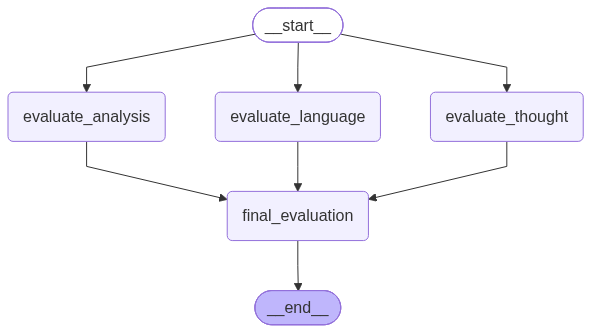

In [13]:
workflow

# 执行工作流

换一篇作文跑完整图，查看并行评审结果。


In [14]:
initial_state = {
    'essay': essay
}

result = workflow.invoke(initial_state)

In [15]:
result

{'essay': '人工智能时代的中国：创新与治理并重\n\n当世界加速迈入人工智能时代，中国正同时扮演技术追赶者与规则参与者的双重角色。与单纯追求模型规模不同，中国更强调把 AI 融入实体经济、公共服务与国家安全，并在发展中探索可落地的治理路径。真正的挑战不仅是算力与算法的竞赛，更是如何让技术进步服务于共同富裕、产业升级与社会信任。\n\n中国的优势首先来自完整的产业体系与海量应用场景。从制造业数字化、智慧城市到医疗影像与金融风控，AI 已在多个垂直领域形成规模化落地。同时，中国在移动互联网、支付与物流上的长期积累，为数据驱动创新提供了土壤。政策层面，国家持续加大对算力基础设施、开源社区与基础研究的投入，推动“人工智能+”与实体经济深度融合。\n\n另一方面，中国也面临不可忽视的挑战。高端芯片与关键基础设施仍受外部约束；高质量、可流通的数据供给仍需制度完善；人才结构在基础理论与前沿交叉领域仍有短板。社会层面，算法公平、隐私保护、深度伪造与就业冲击等问题日益凸显，要求治理能力与技术创新同步提升。\n\n因此，中国在 AI 时代的关键议题，是如何在鼓励创新与防范风险之间找到动态平衡。过于宽松可能放大伦理与安全隐患，过于严格又可能抑制创业活力。可行路径在于分类分级监管、强化开源与标准建设，并鼓励企业在关键行业形成可复制的“可信 AI”实践。\n\n总之，人工智能时代的中国，是一场关于技术、产业与治理协同进化的大型实验。若能把场景优势转化为可持续的创新生态，并建立起兼顾效率与责任的治理框架，中国不仅能提升自身竞争力，也将为全球提供一条不同于西方的发展参考。',
 'language_feedback': '这篇作文语言质量整体较高，属于典型的政论评述风格。具体分析如下：\n\n**优点：**\n1. **用词精准凝练**：如"技术追赶者与规则参与者的双重角色""规模化落地""动态平衡""协同进化"等表述，准确概括了复杂概念，体现了较强的语言驾驭能力。\n2. **句式工整，节奏感好**：善用对仗与排比，如"鼓励创新与防范风险""共同富裕、产业升级与社会信任""效率与责任"，增强了论述的力度和可读性。\n3. **逻辑清晰，层次分明**：从定位到优势，再到挑战，最后落脚于治理路径与总结展望，起承转合自然流畅，过渡词（"另一方面""因此""总之"）使用得当。\n4. **语